# Clustering Analysis

clustering → hyperparameter tuning → Analysis: **which clustering method is correct?**

1000 sentences OK

- Clustering Method
    1. kmeans
    2. greedy
    3. graph-based
    4. dbscan
    5. hierachical clustering
    6. predict to the next sentences

Analysis:
  - what is the right cluster?
  - what makes kmeans/dbscan/greedy correct?

## Dataset & Model

In [1]:
# use wikipedia dataset
import json

filename = "/content/wikipedia_1000_sentences.json"
with open(filename, "r", encoding="utf-8") as f:
  sentences = json.load(f)

print(sentences)

['Anarchism is a political philosophy and movement that is skeptical of all justifications for authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy, typically including nation-states, and capitalism.', 'Anarchism advocates for the replacement of the state with stateless societies and voluntary free associations.', 'As a historically left-wing movement, this reading of anarchism is placed on the farthest left of the political spectrum, usually described as the libertarian wing of the socialist movement (libertarian socialism).', 'Humans have lived in societies without formal hierarchies long before the establishment of states, realms, or empires.', 'With the rise of organised hierarchical bodies, scepticism toward authority also rose.', 'Although traces of anarchist ideas are found all throughout history, modern anarchism emerged from the Enlightenment.', "During the latter half of the 19th and the first decades of the 20th century, the a

In [2]:
print(len(sentences))

1000


In [3]:
import torch
from transformers import BertTokenizer, BertModel, BertForMaskedLM

model_name = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForMaskedLM.from_pretrained(model_name, output_hidden_states=True) # predict next words
model.eval()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

## Get Embeddings (final & intermediate) through BERT

In [4]:
## define the function that extracts Features

def get_features(sentence, model, tokenizer, layer_indices=[-1, -4]):
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True, max_length=128)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)  # Ensure hidden states are returned

    hidden_states = outputs.hidden_states  # Extract all hidden states

    # Extract final layer embedding (CLS token representation)
    final_layer_emb = hidden_states[layer_indices[0]][:, 0, :].squeeze(0).cpu().numpy()

    # Extract intermediate layer embedding (e.g., -4th layer)
    intermediate_layer_emb = hidden_states[layer_indices[1]][:, 0, :].squeeze(0).cpu().numpy()

    return final_layer_emb, intermediate_layer_emb

In [5]:
import numpy as np

batch_size = 32
num_batches = len(sentences) // batch_size + (len(sentences) % batch_size != 0)

final_embeddings = []
intermediate_embeddings = []

for i in range(num_batches):
    batch = sentences[i * batch_size: (i + 1) * batch_size]

    # Get embeddings from model
    batch_final_emb, batch_inter_emb = zip(*[get_features(sent, model, tokenizer) for sent in batch])

    final_embeddings.extend(batch_final_emb)
    intermediate_embeddings.extend(batch_inter_emb)

final_embeddings = np.array(final_embeddings)
intermediate_embeddings = np.array(intermediate_embeddings)

print("Final embedding shape:", final_embeddings.shape)
print("Intermediate embedding shape:", intermediate_embeddings.shape)

Final embedding shape: (1000, 768)
Intermediate embedding shape: (1000, 768)


## Clustering
1. Greedy
2. graph-based
3. K-means
4. dbscan

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

final_cos_similar = cosine_similarity(final_embeddings)
inter_cos_similar = cosine_similarity(intermediate_embeddings)

In [15]:
print("Cosine Similarity of Final Embeddings")
print(np.round(final_cos_similar[:5, :5], 2))
print("Cosine Similarity of Intermediate Embeddings")
print(np.round(inter_cos_similar[:5, :5], 2))

Cosine Similarity of Final Embeddings
[[1.   0.82 0.84 0.71 0.75]
 [0.82 1.   0.84 0.73 0.84]
 [0.84 0.84 1.   0.76 0.83]
 [0.71 0.73 0.76 1.   0.75]
 [0.75 0.84 0.83 0.75 1.  ]]
Cosine Similarity of Intermediate Embeddings
[[1.   0.72 0.85 0.69 0.71]
 [0.72 1.   0.77 0.79 0.86]
 [0.85 0.77 1.   0.82 0.8 ]
 [0.69 0.79 0.82 1.   0.84]
 [0.71 0.86 0.8  0.84 1.  ]]


In [13]:
thres = 0.8
n = len(sentences)

In [6]:
!pip install kneed

In [9]:
from scipy.stats import linregress
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import networkx as nx
import matplotlib.pyplot as plt
from kneed import KneeLocator

In [10]:
# 1. Simple Greedy Approcah
def grouping(cos_similar, n, thres):
  groups = []
  visited = set()

  for i in range(n):
    if i in visited:
      continue

    group = [i]
    visited.add(i)

    for j in range(n):
      if j not in visited and cos_similar[i][j] >= thres:
        group.append(j)
        visited.add(j)

    groups.append(group)

  return groups


# 2. graph-based grouping (connected componenets) - clustering
def graph_based_grouping(cos_similar, n, thres):
  graph = nx.Graph()

  graph.add_nodes_from(range(n))

  for i in range(n):
    for j in range(i+1, n):
      if cos_similar[i][j] >= thres:
        graph.add_edge(i, j)

  groups = [list(component) for component in nx.connected_components(graph)]

  return groups


# 3. Clustering using DBSCAN
def clustering_grouping(embedding, thres):
  eps = 1 - thres
  clustering = DBSCAN(eps=eps, min_samples=2, metric="cosine").fit(embedding)
  labels = clustering.labels_

  # print("The number of clusters:", len(set(labels))-(1 if -1 in labels else 0))

  groups = {}
  for idx, label in enumerate(labels):
    if label not in groups:
      groups[label] = []
    groups[label].append(idx)
  return list(groups.values())


# 4. Kmeans - elbow analysis
def kmeans_elbow(embeddings, k_range):
    inertias = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans.fit(embeddings)
        inertias.append(kmeans.inertia_)
    return inertias # within-cluster sum of squres

def plot_elbow_with_knee(k_range, inertias, title="KMeans Elbow Plot"):
    k_vals = list(k_range)

    kl = KneeLocator(k_vals, inertias, curve="convex", direction="decreasing")
    optimal_k = kl.elbow

    plt.figure(figsize=(8, 5))
    plt.plot(k_vals, inertias, marker='o', label="Inertia")
    if optimal_k:
        plt.axvline(optimal_k, color='red', linestyle='--', label=f"Optimal k = {optimal_k}")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return optimal_k

### 1. Greedy clustering

In [16]:
# greedy
final_greedy = grouping(final_cos_similar, n, thres)
inter_greedy = grouping(inter_cos_similar, n, thres)

In [30]:
print(f"Greedy Clustering (Final Layer): {len(final_greedy)} clusters")
print(f"Greedy Clustering (Intermediate Layer): {len(inter_greedy)} clusters")

Greedy Clustering (Final Layer): 136 clusters
Greedy Clustering (Intermediate Layer): 40 clusters


In [31]:
def get_labels_from_groups(groups, n_samples):
    labels = [-1] * n_samples
    for cluster_id, group in enumerate(groups):
        for idx in group:
            labels[idx] = cluster_id
    return labels

In [34]:
from sklearn.metrics import silhouette_score

# Final Greedy
labels = get_labels_from_groups(final_greedy, n_samples=len(final_embeddings))
score = silhouette_score(final_embeddings, labels, metric='cosine')
print(f"Final Greedy Silhouette: {score:.3f}")

# Intermediate Greedy
labels = get_labels_from_groups(inter_greedy, n_samples=len(intermediate_embeddings))
score = silhouette_score(intermediate_embeddings, labels, metric='cosine')
print(f"Intermediate Greedy Silhouette: {score:.3f}")

Final Greedy Silhouette: -0.041
Intermediate Greedy Silhouette: -0.004


### 1-2. GREEDY CLUSTER ANALYSIS
- Final Layer Greedy Clustering
  - Number of clusters: 136
  - Silhouette Score: −0.041
- Intermediate Layer Greedy Clustering
  - Number of clusters: 40
  - Silhouette Score: −0.004

Interpretation:
- Both scores are slightly negative, indicating that many samples may be closer to samples in other clusters than to those in their own cluster — a sign of poor clustering quality.
- The intermediate layer yields fewer clusters and a less negative score (−0.004), implying that the intermediate representations might encode slightly more clusterable structures than final-layer embeddings in this greedy setup.
- The final layer yields many small clusters (136) but results in worse silhouette cohesion (−0.041), suggesting over-segmentation.

Takeaway:
  - Greedy clustering, though simple, does not perform well in this scenario — both quantitatively (via silhouette) and structurally (too many or too few clusters). The intermediate layer is slightly more promising but still insufficient on its own.

### 2. Graph-based Clustering

In [17]:
# graph
final_graph = graph_based_grouping(final_cos_similar, n, thres)
inter_graph = graph_based_grouping(inter_cos_similar, n, thres)

In [33]:
print(f"Graph-based Clustering (Final Layer): {len(final_graph)} clusters")
print(f"Graph-based Clustering (Intermediate Layer): {len(inter_graph)} clusters")

Graph-based Clustering (Final Layer): 15 clusters
Graph-based Clustering (Intermediate Layer): 7 clusters


In [37]:
# Final Graph
labels = get_labels_from_groups(final_graph, n_samples=len(final_embeddings))
score = silhouette_score(final_embeddings, labels, metric='cosine')
print(f"Final Graph Silhouette: {score:.3f}")

# Intermediate Graph
labels = get_labels_from_groups(inter_graph, n_samples=len(intermediate_embeddings))
score = silhouette_score(intermediate_embeddings, labels, metric='cosine')
print(f"Intermediate Graph Silhouette: {score:.3f}")

Final Graph Silhouette: 0.096
Intermediate Graph Silhouette: 0.411


### 2-2. GRAPH-BASED CLUSTER ANALYSIS
- Final Layer Graph-based Clustering
  - Silhouette Score: 0.096
- Intermediate Layer Graph-based Clustering
  - Silhouette Score: 0.411

Interpretation:
- The silhouette score for the intermediate layer (0.411) is significantly higher than that of the final layer (0.096), suggesting clearer and more cohesive clusters from intermediate representations.
- A silhouette score above 0.4 generally indicates that the clustering is reasonable and meaningful, especially in high-dimensional spaces like sentence embeddings.
- The graph-based approach outperformed greedy and DBSCAN methods (which had negative scores) and even KMeans (which yielded scores around 0.05).
- The intermediate-layer embeddings likely capture semantically rich relationships before final task-specific transformations occur in BERT.

Conclusion:
- Graph-based clustering using intermediate BERT embeddings achieves the best clustering quality among all methods evaluated so far. This approach effectively leverages similarity structure and appears most suitable for your sentence clustering task.

### 3. DBSCAN Clustering
- dbcsan hyperparameter tuning

In [22]:
def tune_dbscan(embeddings, threshold_list):
    results = []
    for thres in threshold_list:
        eps = 1 - thres
        dbscan = DBSCAN(eps=eps, min_samples=2, metric="cosine").fit(embeddings)
        labels = dbscan.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        results.append((thres, n_clusters, n_noise))
    return results

In [23]:
thresholds = [0.7, 0.75, 0.8, 0.85, 0.9]

final_dbscan_results = tune_dbscan(final_embeddings, thresholds)
inter_dbscan_results = tune_dbscan(intermediate_embeddings, thresholds)

print("FINAL EMBEDDINGS")
for thres, n_clusters, n_noise in final_dbscan_results:
    print(f"Threshold: {thres}, #Clusters: {n_clusters}, Noise Points: {n_noise}")

print("INTERMEDIATE EMBEDDINGS")
for thres, n_clusters, n_noise in inter_dbscan_results:
    print(f"Threshold: {thres}, #Clusters: {n_clusters}, Noise Points: {n_noise}")

FINAL EMBEDDINGS
Threshold: 0.7, #Clusters: 2, Noise Points: 2
Threshold: 0.75, #Clusters: 1, Noise Points: 7
Threshold: 0.8, #Clusters: 1, Noise Points: 14
Threshold: 0.85, #Clusters: 2, Noise Points: 95
Threshold: 0.9, #Clusters: 61, Noise Points: 502
INTERMEDIATE EMBEDDINGS
Threshold: 0.7, #Clusters: 1, Noise Points: 0
Threshold: 0.75, #Clusters: 1, Noise Points: 1
Threshold: 0.8, #Clusters: 2, Noise Points: 5
Threshold: 0.85, #Clusters: 2, Noise Points: 16
Threshold: 0.9, #Clusters: 7, Noise Points: 85


In [24]:
from sklearn.metrics import silhouette_score

def evaluate_clustering(embeddings, labels):
    if len(set(labels)) > 1 and -1 not in set(labels):  # avoid noise only or one cluster
        score = silhouette_score(embeddings, labels, metric="cosine")
    else:
        score = -1
    return score


In [27]:
print("FINAL EMBEDDINGS")
for thres in thresholds:
    eps = 1 - thres
    labels = DBSCAN(eps=eps, min_samples=2, metric="cosine").fit_predict(final_embeddings)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"Threshold: {thres}, #Clusters: {n_clusters}, Noise: {n_noise}")

    score = evaluate_clustering(final_embeddings, labels)
    print(f"DBSCAN threshold {thres}: Silhouette = {score:.3f}")

print("INTERMEDIATE EMBEDDINGS")
for thres in thresholds:
    eps = 1 - thres
    labels = DBSCAN(eps=eps, min_samples=2, metric="cosine").fit_predict(intermediate_embeddings)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"Threshold: {thres}, #Clusters: {n_clusters}, Noise: {n_noise}")

    score = evaluate_clustering(intermediate_embeddings, labels)
    print(f"DBSCAN threshold {thres}: Silhouette = {score:.3f}")

FINAL EMBEDDINGS
Threshold: 0.7, #Clusters: 2, Noise: 2
DBSCAN threshold 0.7: Silhouette = -1.000
Threshold: 0.75, #Clusters: 1, Noise: 7
DBSCAN threshold 0.75: Silhouette = -1.000
Threshold: 0.8, #Clusters: 1, Noise: 14
DBSCAN threshold 0.8: Silhouette = -1.000
Threshold: 0.85, #Clusters: 2, Noise: 95
DBSCAN threshold 0.85: Silhouette = -1.000
Threshold: 0.9, #Clusters: 61, Noise: 502
DBSCAN threshold 0.9: Silhouette = -1.000
INTERMEDIATE EMBEDDINGS
Threshold: 0.7, #Clusters: 1, Noise: 0
DBSCAN threshold 0.7: Silhouette = -1.000
Threshold: 0.75, #Clusters: 1, Noise: 1
DBSCAN threshold 0.75: Silhouette = -1.000
Threshold: 0.8, #Clusters: 2, Noise: 5
DBSCAN threshold 0.8: Silhouette = -1.000
Threshold: 0.85, #Clusters: 2, Noise: 16
DBSCAN threshold 0.85: Silhouette = -1.000
Threshold: 0.9, #Clusters: 7, Noise: 85
DBSCAN threshold 0.9: Silhouette = -1.000


### 3-2. DBSCAN TUNING ANALYSIS
Based on the results shown, DBSCAN appears to have failed to produce meaningful clusters across all tested thresholds. The evidence is as follows:
1. Silhouette Score = -1.000 for All Cases
  -  A silhouette score of -1.0 strongly suggests failed clustering.
  - This typically occurs when:
    - All data points are assigned to a single cluster, or
    - Clusters are formed incorrectly or arbitrarily.
2. Threshold-wise breakdown
  - threhold(0.7): Too few clusters / Collapse
  - threshold(0.75): All data collapsed into a single cluster
  - threhold(0.8): Still collapsed or sparse
  - threhold(0.85): High noise, tiny clusters
  - threhold(0.9) Many small clusters, extremely noisy


Conclusion:
- DBSCAN is not a suitable clustering method for this embedding space as-is.
- High-dimensional embedding spaces often cause DBSCAN to perform poorly, especially with cosine similarity.
- The mapping eps = 1 - threshold may not align well with the actual distance distribution.

### 4. K-means Clustering

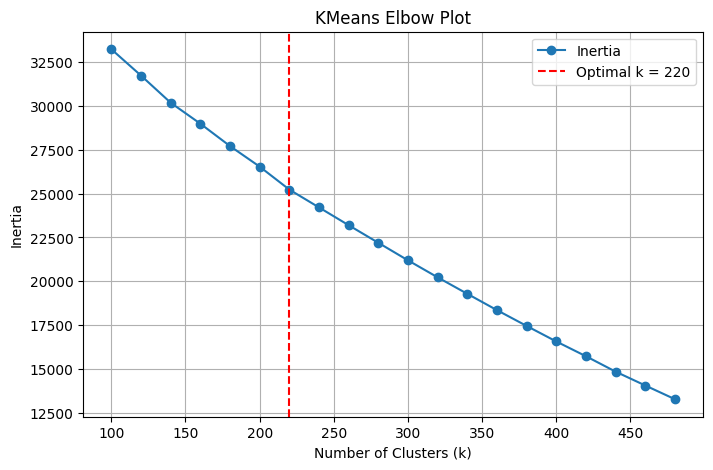

KMeans final embeddings: (k=220


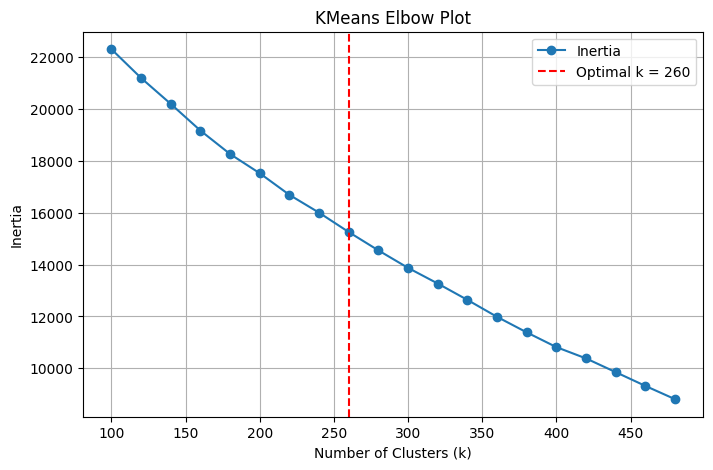

KMeans intermediate embeddings: (k=260


In [28]:
# kmeans
k_range = range(100, 500, 20)

# final embeddings
inertias = kmeans_elbow(final_embeddings, k_range)
final_optimal_k = plot_elbow_with_knee(k_range, inertias)
print(f"KMeans final embeddings: (k={final_optimal_k}")

# Intermediate embeddings
inertias = kmeans_elbow(intermediate_embeddings, k_range)
inter_optimal_k = plot_elbow_with_knee(k_range, inertias)
print(f"KMeans intermediate embeddings: (k={inter_optimal_k}")

In [29]:
# final
kmeans = KMeans(n_clusters=final_optimal_k, random_state=42, n_init='auto')
labels = kmeans.fit_predict(final_embeddings)
score = evaluate_clustering(final_embeddings, labels)
print(f"KMeans (k={final_optimal_k}): Silhouette = {score:.3f}")

# intermediate
kmeans = KMeans(n_clusters=inter_optimal_k, random_state=42, n_init='auto')
labels = kmeans.fit_predict(intermediate_embeddings)
score = evaluate_clustering(intermediate_embeddings, labels)
print(f"KMeans (k={inter_optimal_k}): Silhouette = {score:.3f}")

KMeans (k=220): Silhouette = 0.052
KMeans (k=260): Silhouette = 0.050


### 4-2. KMEANS TUNING ANALYSIS
After tuning the number of clusters (k) using the Elbow method, the KMeans clustering results are summarized as follows:
- The silhouette scores for both final and intermediate embeddings are very low (~0.05).
- A low silhouette score suggests:
  - Poor separation between clusters.
  - Possible over-segmentation (too many clusters).
 - The optimal k values (220 and 260) are relatively large compared to the dataset size (1000 sentences), suggesting many small clusters.

Comparison with DBSCAN:
- KMeans: silhouette(0.052), clusters formed(220–260)
  - Large number of small clusters, marginal structure captured
- DBSCAN: silhouette(-1.000)	clusters formed(Mostly 1–2 or 61)
  - Completely failed to form useful clusters
- KMeans performs better than DBSCAN on both intermediate and final BERT embeddings, though the scores are still suboptimal.

### 5. Next token prediction
- model: gpt

In [52]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from collections import defaultdict
import torch

# Load GPT-2
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

token_clusters = defaultdict(list)

for sent in sentences:
    # Tokenize and encode with GPT2
    inputs = tokenizer(sent, return_tensors="pt")
    input_ids = inputs["input_ids"]

    with torch.no_grad():
        outputs = model(input_ids)
        logits = outputs.logits

    # Get last position's prediction (next token)
    next_token_logits = logits[0, -1]  # shape: [vocab_size]
    predicted_token_id = torch.argmax(next_token_logits).item()
    predicted_token = tokenizer.decode([predicted_token_id])

    # Group sentence by predicted token
    token_clusters[predicted_token].append(sent)

# Print Top Clusters
for token, cluster_sents in sorted(token_clusters.items(), key=lambda x: -len(x[1]))[:10]:
    print(f"\nToken: '{token}' — {len(cluster_sents)} sentences")
    for s in cluster_sents[:5]:  # Show up to 5 samples per token
        print("  -", s)



Token: '
' — 718 sentences
  - As a historically left-wing movement, this reading of anarchism is placed on the farthest left of the political spectrum, usually described as the libertarian wing of the socialist movement (libertarian socialism).
  - During the latter half of the 19th and the first decades of the 20th century, the anarchist movement flourished in most parts of the world and had a significant role in workers' struggles for emancipation.
  - Anarchists have taken part in several revolutions, most notably in the Paris Commune, the Russian Civil War and the Spanish Civil War, whose end marked the end of the classical era of anarchism.
  - In the last decades of the 20th and into the 21st century, the anarchist movement has been resurgent once more, growing in popularity and influence within anti-capitalist, anti-war and anti-globalisation movements.
  - Anarchists employ diverse approaches, which may be generally divided into revolutionary and evolutionary strategies; ther

In [53]:
def get_gpt_embedding(sent):
    inputs = tokenizer(sent, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.transformer(**inputs)
        hidden_states = outputs.last_hidden_state  # shape: [1, seq_len, hidden_size]
        mean_embedding = hidden_states.mean(dim=1).squeeze(0)  # shape: [hidden_size]
    return mean_embedding.cpu().numpy()

In [54]:
all_embeddings = [get_gpt_embedding(sent) for sent in sentences]

label_map = {}
for i, (token, sents) in enumerate(token_clusters.items()):
    for s in sents:
        label_map[s] = i

labels = [label_map[s] for s in sentences]

score = silhouette_score(all_embeddings, labels, metric="cosine")
print(f"\nSilhouette Score for GPT2 next-token clustering: {score:.4f}")


Silhouette Score for GPT2 next-token clustering: -0.5086


### 5-2. GPT-BASED CLUSTERING ANALYSIS
The Silhouette Score measures the quality of clustering by evaluating:
  - Cohesion: how close samples in the same cluster are to each other
  - Separation: how far apart different clusters are
The score ranges from:
  - +1 → perfectly well-clustered
  - 0 → overlapping clusters
  - < 0 → poor clustering; samples may be assigned to the wrong clusters
- A score of –0.5086 is quite poor and suggests that:

Interpretation:
- The sentence embeddings assigned to the same cluster (i.e., those with the same predicted next token) are not close to each other in embedding space.
- Worse, these samples are often closer to samples in other clusters, indicating misgrouping.
- This could indicate:
  - Same next-token predictions do not imply semantic similarity
  - GPT2 may predict the same token in semantically different contexts.
- Too many clusters based on token predictions
- If the number of clusters (i.e., unique predicted tokens) is large and some clusters are small, the Silhouette Score tends to drop.

## Linear Regeression plot based on best token

In [40]:
def get_count(groups):
  group_counts = []
  word_counts = []

  for group in groups:
    group_counts.append(len(group))

    unique_words = set() # prevent duplicates
    for idx in group:
      unique_words.update(sentences[idx].split())
    word_counts.append(len(unique_words))
  return group_counts, word_counts # num of sentence per group, num of word per group

In [41]:
print("--Graph Grouping--")
graph_group_counts_final, graph_word_counts_final = get_count(final_graph)
graph_group_counts_inter, graph_word_counts_inter = get_count(inter_graph)

print("Final layers' Group Counts of first 5th group:", graph_group_counts_final[:5])
print("Intermediate layers' Group Counts of first 5th group:", graph_group_counts_inter[:5])

--Graph Grouping--
Final layers' Group Counts of first 5th group: [986, 1, 1, 1, 1]
Intermediate layers' Group Counts of first 5th group: [993, 1, 2, 1, 1]


In [42]:
def rearrange_decreasing_order(counts_vector):
  counts_vector = np.array(counts_vector)
  sorted_indices = np.argsort(-counts_vector)
  sorted_sent_counts = counts_vector[sorted_indices]
  return sorted_sent_counts

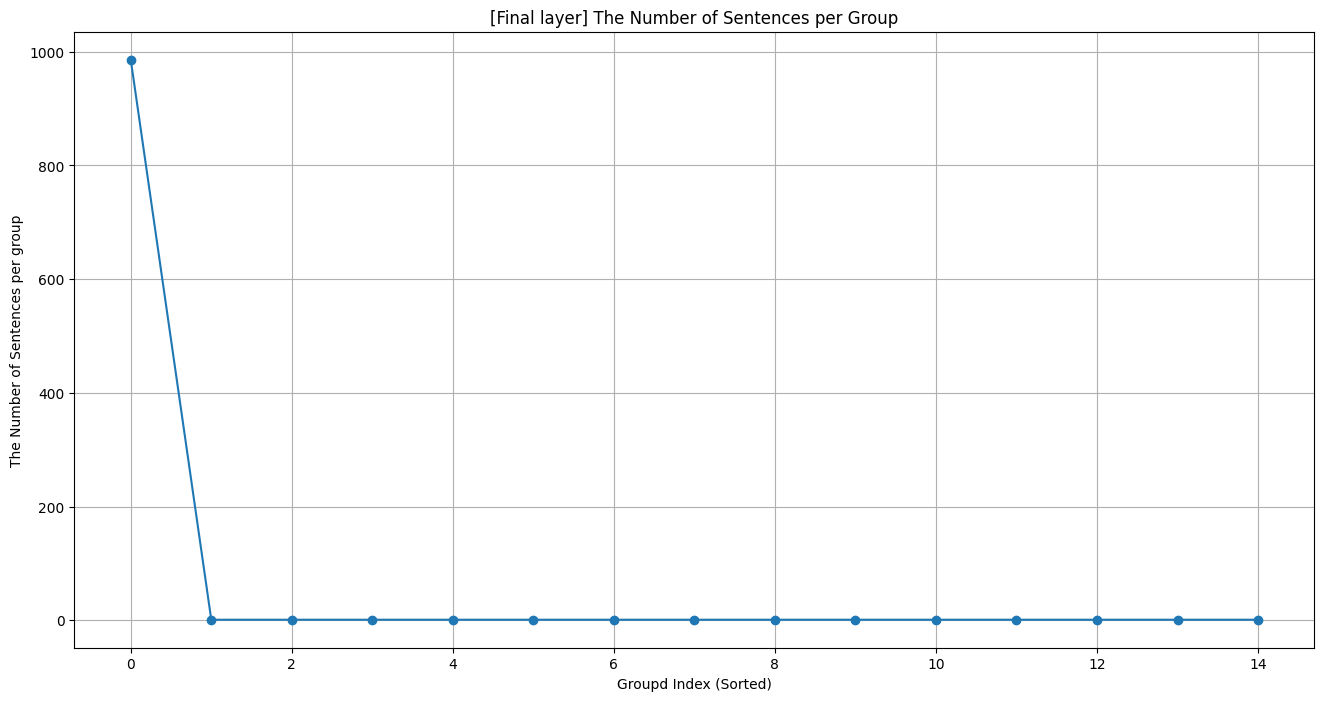

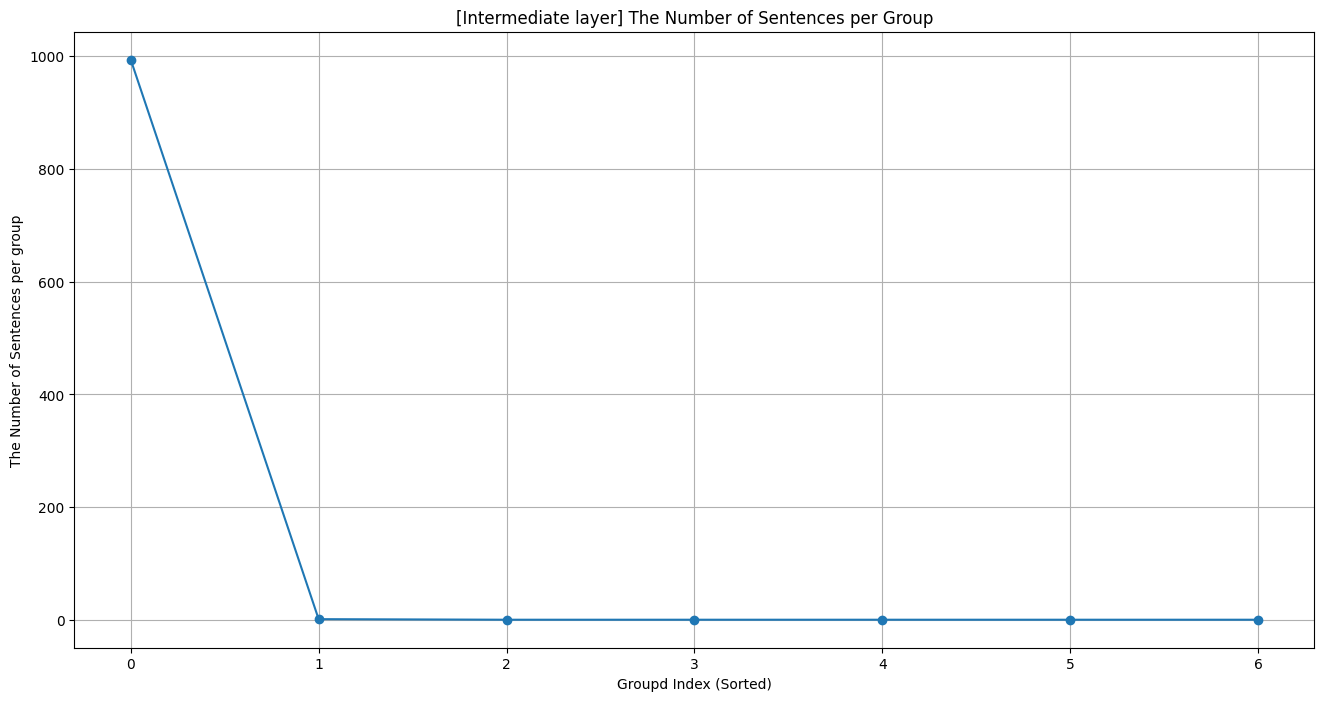

In [43]:
# rearrange in decreaing order (ranking)
sorted_sent_counts_final = rearrange_decreasing_order(graph_group_counts_final)
sorted_sent_counts_inter = rearrange_decreasing_order(graph_group_counts_inter)

def plotting(flag, sorted_sent_counts):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"
  # x-axis
  plt.figure(figsize=(16,8))
  plt.plot(range(len(sorted_sent_counts)), sorted_sent_counts, marker='o', linestyle="-")


  plt.xlabel("Groupd Index (Sorted)")
  plt.ylabel("The Number of Sentences per group")
  plt.title(detail + " The Number of Sentences per Group")
  plt.grid(True)

  plt.show()

plotting(True, sorted_sent_counts_final)
plotting(False, sorted_sent_counts_inter)

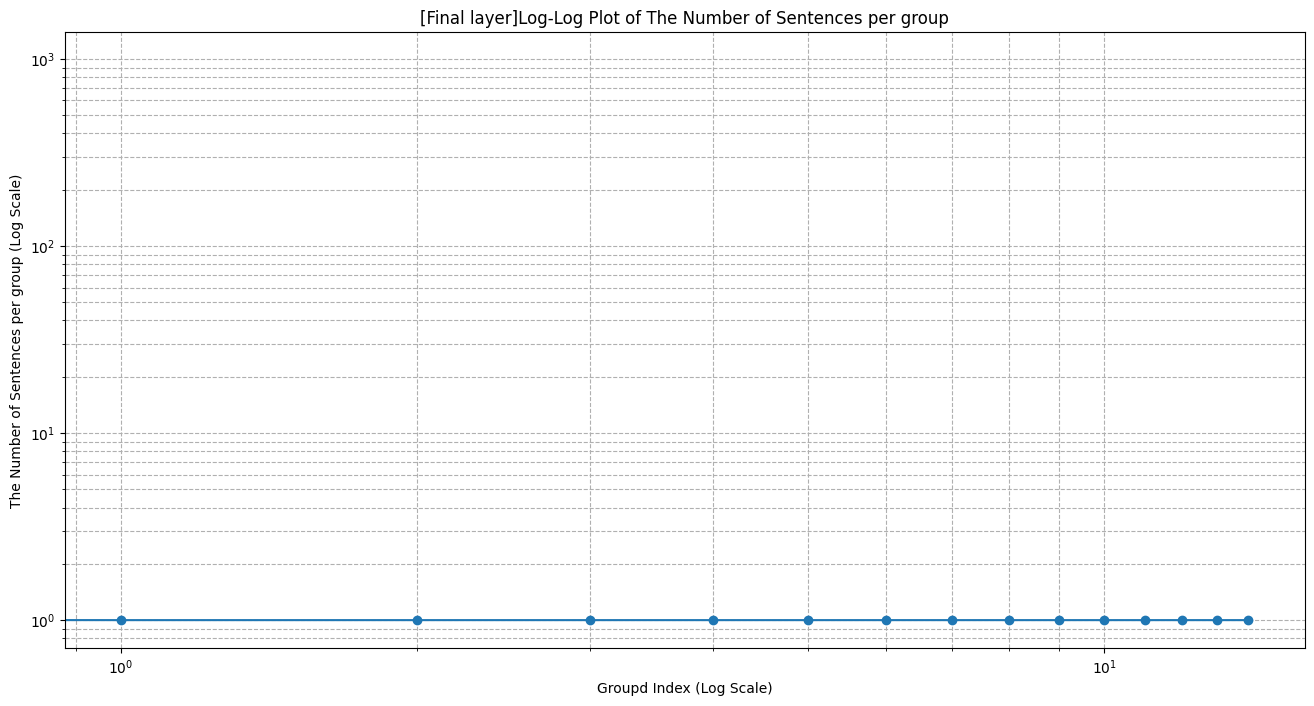

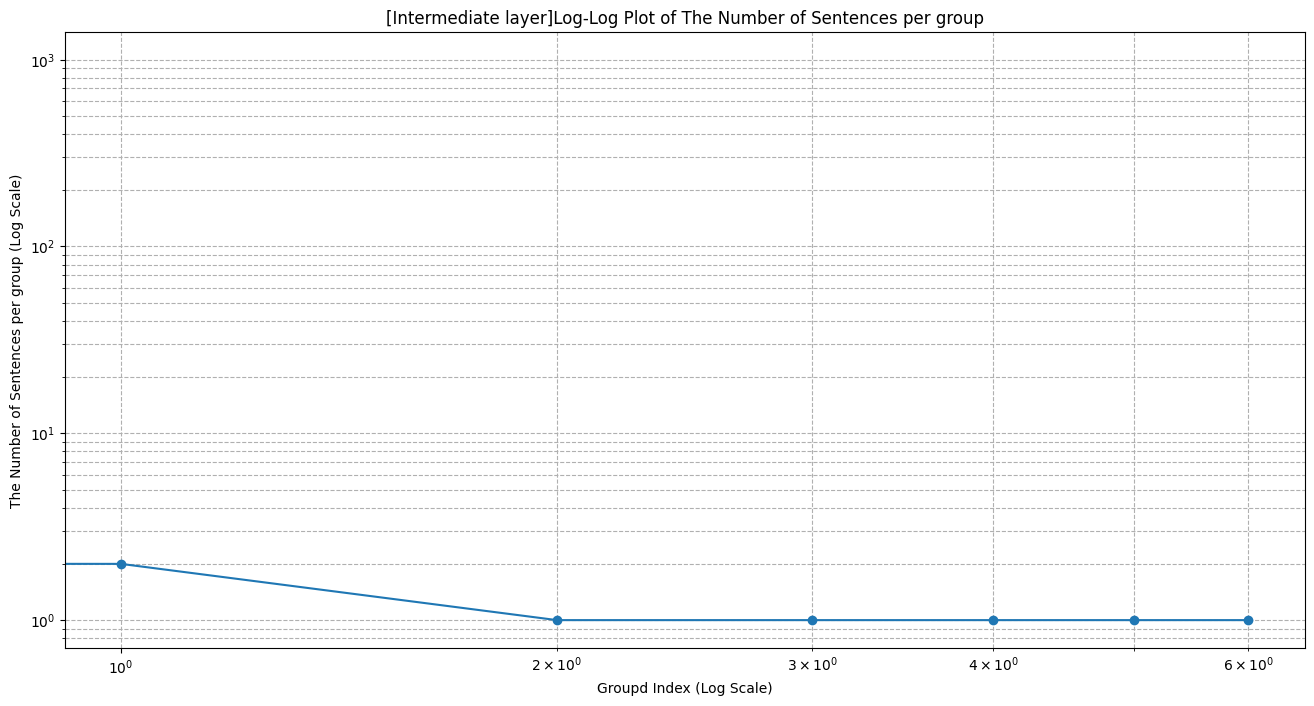

In [44]:
# Also plot the log log plot using the count matrix.
def loglog_plotting(flag, sorted_sent_counts):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"
  plt.figure(figsize=(16,8))
  plt.loglog(range(len(sorted_sent_counts)), sorted_sent_counts, marker="o", linestyle="-")

  plt.xlabel("Groupd Index (Log Scale)")
  plt.ylabel("The Number of Sentences per group (Log Scale)")
  plt.title(detail + "Log-Log Plot of The Number of Sentences per group")
  plt.grid(True, which="both", linestyle="--")

  plt.show()

loglog_plotting(True, sorted_sent_counts_final)
loglog_plotting(False, sorted_sent_counts_inter)

In [45]:
from scipy.stats import linregress

def linear_regression(sorted_sent_counts):
  x = np.log10(np.arange(1, len(sorted_sent_counts)+1))
  y = np.log10(sorted_sent_counts)

  # linear regression
  slope, intercept, r_val, p_val, std_err = linregress(x, y)

  # regression prediction
  y_pred = slope * x + intercept

  return x, y, slope, intercept, r_val, p_val, y_pred

In [46]:
def return_linear_regression_result(flag, sorted_sent_counts):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"

  x, y, slope, intercept, r_val, p_val, y_pred = linear_regression(sorted_sent_counts)

  print(detail + "Linear Regression Prediction: y = slope * x + intercept")
  print(f"y ={slope:.2f}x + {intercept:.2f}")

  print(f"Linear Regression Results:")
  print(f"   - Slope: {slope:.4f}")
  print(f"   - Intercept: {intercept:.4f}")
  print(f"   - R-squared: {r_val**2:.4f}")
  print(f"   - P-value: {p_val:.4e}")

In [47]:
# rearrange in decreaing order (ranking)
linear_regression(sorted_sent_counts_final)
linear_regression(sorted_sent_counts_inter)

(array([0.        , 0.30103   , 0.47712125, 0.60205999, 0.69897   ,
        0.77815125, 0.84509804]),
 array([2.99694925, 0.30103   , 0.        , 0.        , 0.        ,
        0.        , 0.        ]),
 np.float64(-3.116011173171814),
 np.float64(2.1192563090880188),
 np.float64(-0.8278803711168231),
 np.float64(0.021466593713501562),
 array([ 2.11925631,  1.18124348,  0.63254115,  0.24323065, -0.05874203,
        -0.30547168, -0.51407863]))

In [48]:
def linear_regression_plotting(flag, sorted_sent_counts, model):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"

  x, y, slope, intercept, r_val, p_val, y_pred = linear_regression(sorted_sent_counts)

  plt.figure(figsize=(16,8))
  plt.scatter(x, y, label="Sentences counts (Log-Log)", alpha=0.8, marker="o")
  plt.plot(x, y_pred, color = "red", label=f"Linear Fit: y={slope:.2f}x + {intercept:.2f}")
  plt.text(0.1, 1.2, f"$R^2$ = {r_val**2:.4f}", fontsize=14, color="black")

  plt.xlabel("Group Index (Log scale)")
  plt.ylabel("The Number of Sentences per group (Log scale)")
  plt.title(detail + "Linear Regression on Log-Log Scale - " + model)
  plt.legend()
  plt.grid(True)

  plt.show()

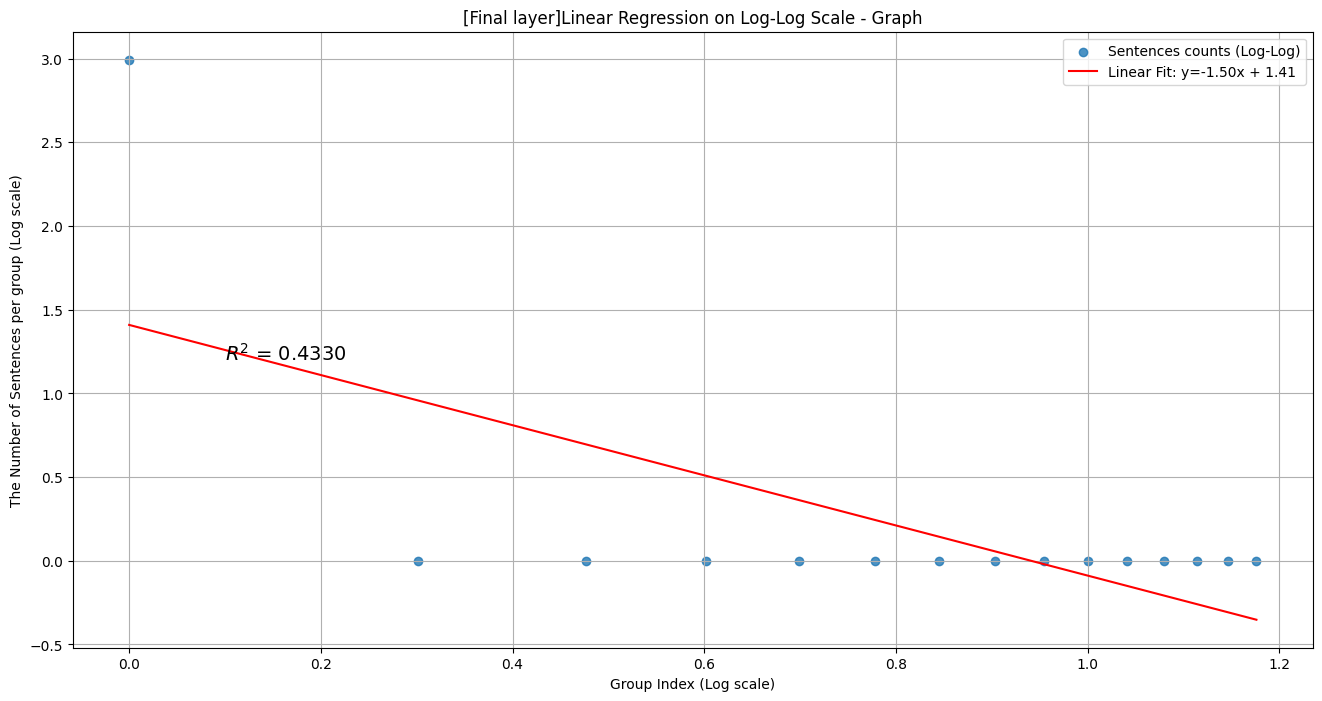

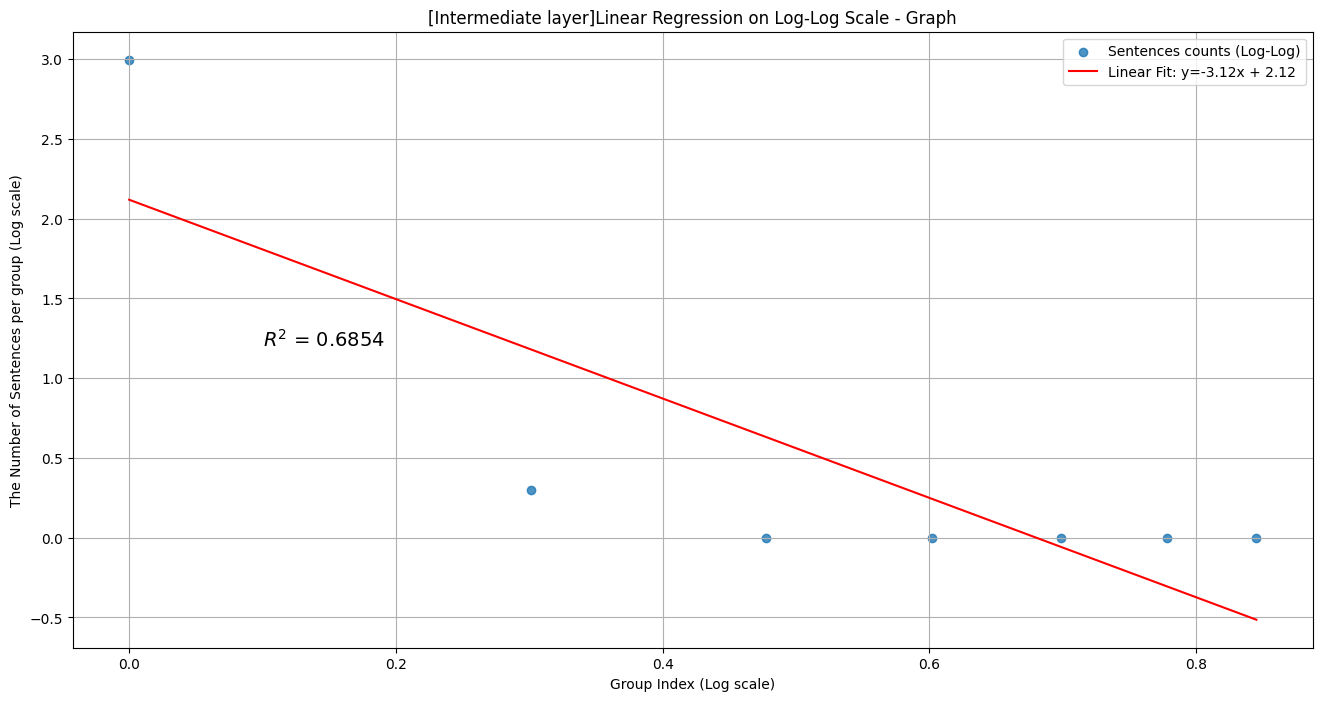

In [49]:
linear_regression_plotting(True, sorted_sent_counts_final, "Graph")
linear_regression_plotting(False, sorted_sent_counts_inter, "Graph")

## best model: intermediate graph

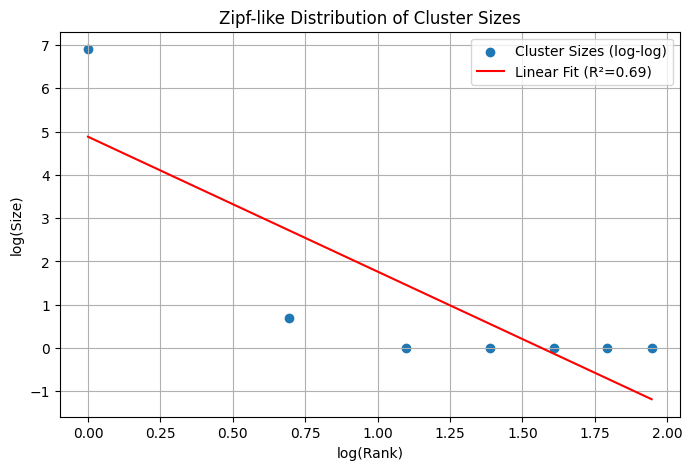

Linear Regression Slope: -3.1160
Intercept: 4.8798
R² Score: 0.6854


In [55]:
from sklearn.linear_model import LinearRegression

# Step 1: Count sentences per cluster
cluster_sizes = [len(cluster) for cluster in inter_graph]  # or final_graph
cluster_sizes.sort(reverse=True)

# Step 2: Prepare data for regression
ranks = np.arange(1, len(cluster_sizes) + 1)
sizes = np.array(cluster_sizes)

# Optionally log-log for Zipf analysis
log_ranks = np.log(ranks).reshape(-1, 1)
log_sizes = np.log(sizes)

# Step 3: Fit linear regression
model = LinearRegression()
model.fit(log_ranks, log_sizes)
slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(log_ranks, log_sizes)

# Step 4: Plot
plt.figure(figsize=(8, 5))
plt.scatter(log_ranks, log_sizes, label="Cluster Sizes (log-log)")
plt.plot(log_ranks, model.predict(log_ranks), color="red", label=f"Linear Fit (R²={r2:.2f})")
plt.xlabel("log(Rank)")
plt.ylabel("log(Size)")
plt.title("Zipf-like Distribution of Cluster Sizes")
plt.legend()
plt.grid(True)
plt.show()

# Optional: print regression stats
print(f"Linear Regression Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R² Score: {r2:.4f}")
